# Customer Feature Engineering

In [ ]:
import pandas as pd
customers_cleaned = pd.read_csv("cleaned_supplyguard_data/customers_cleaned.csv")



In [ ]:
shipments_cleaned = pd.read_csv("cleaned_supplyguard_data/shipments_cleaned.csv")
shipments_cleaned

In [ ]:
deliveries_cleaned = pd.read_csv("cleaned_supplyguard_data/deliveries_cleaned.csv")
deliveries_cleaned

In [ ]:
#Merging datasets (customers & shipments)
mergedcusship = pd.merge(
    customers_cleaned,
    shipments_cleaned,
    on='customer_id',
    how ='left'
)

In [ ]:
all3merged = mergedcusship.merge(deliveries_cleaned)

In [ ]:
all3merged

In [ ]:
#Customer shipment count
all3merged['customer_shipment_count'] = (
all3merged.groupby('customer_id')['shipment_id']
.transform('count')
)

In [ ]:
all3merged

In [ ]:
#Creating customer total shipments
all3merged['customer_total_shipping_value'] = (
all3merged.groupby('customer_id')['declared_value_zar'] 
.transform('sum')
)

In [ ]:
all3merged


In [ ]:
#Creating customer average shipment
all3merged['customer_average_shipment_value'] = (
all3merged.groupby('customer_id')['declared_value_zar'].
transform('mean')
)

In [ ]:
all3merged

In [ ]:
all3merged['customer_average_delivery_time'] = (
all3merged.groupby('customer_id')['delivery_duration_hours']
.transform('mean')
)

In [ ]:
#All 4 features
all3merged

In [ ]:
#all3merged[["customer_id","customer_shipment_count","customer_total_shipping_value","customer_average_shipment_value","customer_average_delivery_time"]].drop_duplicates().merge(customers_cleaned).to_csv("final_data/customer_final.csv")

# Shipment Features

In [ ]:
shipments_cleaned 

In [ ]:
deliveries_cleaned

In [ ]:
delivery_labels_cleaned = pd.read_csv("cleaned_supplyguard_data/delivery_labels_cleaned.csv")
delivery_labels_cleaned

In [ ]:
shipdeliv = pd.merge(
    shipments_cleaned,
    deliveries_cleaned,
    on="shipment_id",
    how="left"
)

In [ ]:
shipdeliv

In [ ]:
finalmerge = shipdeliv.merge(delivery_labels_cleaned)

In [ ]:
finalmerge

In [ ]:
finalmerge['shipment_weight'] = (
finalmerge.groupby('shipment_id')['weight_kg']
.transform('sum')
)

In [ ]:
finalmerge['shipment_distance'] = (
finalmerge.groupby('shipment_id')['distance_km']
.transform('sum')
)

In [ ]:
finalmerge['delivery_duration'] = (
finalmerge.groupby('delivery_id')['delivery_duration_hours']
.transform('sum')
)

In [ ]:
finalmerge['late_delivery_flag'] = (
finalmerge.groupby('delivery_id')['is_late']
.transform('sum')
)

In [ ]:
finalmerge

In [ ]:
#finalmerge[["shipment_id","shipment_weight","shipment_distance","delivery_duration","late_delivery_flag"]].drop_duplicates().merge(shipments_cleaned).to_csv("final_data/shipment_final.csv", index=False)

# Delivery Feature Engineering

In [ ]:
import pandas as pd
deliveries_cleaned = pd.read_csv("cleaned_supplyguard_data/deliveries_cleaned.csv")

In [ ]:
deliveries_cleaned['delivery_date'] = pd.to_datetime(deliveries_cleaned['delivery_date'])

In [ ]:
deliveries_cleaned["delivery_weekday"] = deliveries_cleaned["delivery_date"].dt.weekday

In [ ]:
deliveries_cleaned

In [ ]:
finalmerge

In [ ]:
all3merged

In [ ]:
deliveryMerged = pd.merge(
    finalmerge,
    all3merged,
    on="delivery_id",
    how="left"
)

In [ ]:
deliveryMerged

In [ ]:
lastMerged = deliveryMerged.merge(deliveries_cleaned)

In [ ]:
lastMerged

In [ ]:
lastMerged['customer_average_distance'] = (
lastMerged.groupby('customer_id_x')['delivery_distance_km']
.transform('mean')
)
lastMerged["distance_vs_average"] =(lastMerged["delivery_distance_km"] / lastMerged["customer_average_distance"])
lastMerged

In [ ]:
lastMerged['delivery_delay_hours'] = (
lastMerged.groupby('delivery_distance_km')['delivery_duration_hours']
.transform('mean')
)
lastMerged

In [ ]:
lastMerged['late_delivery_flag'] = (
lastMerged.groupby('delivery_id')['delivery_duration_hours']
.transform('sum')
)

In [ ]:
lastMerged['long_distance_flag'] = (
lastMerged.groupby('delivery_id')['delivery_duration_hours']
.transform('mean')
)

In [ ]:
lastMerged['repeat_delay_flag'] = (
lastMerged.groupby('attempt_number')['delivery_duration_hours']
.transform('count')
)
lastMerged

In [ ]:
#lastMerged[["delivery_id","delivery_hour", "delivery_weekday", "customer_shipment_count", "customer_average_delivery_time", "distance_vs_average", "delivery_delay_hours", "late_delivery_flag", "long_distance_flag", "repeat_delay_flag"]].drop_duplicates().merge(deliveries_cleaned).to_csv("final_data/deliveries_final.csv", index=False)

# DELIVERY DATE FEATURE (DATE FEATURES:)

In [ ]:
#Converting object to datetime
deliveries_cleaned['delivery_date'] = pd.to_datetime(deliveries_cleaned['delivery_date'])

In [ ]:
deliveries_cleaned["year"] = deliveries_cleaned["delivery_date"].dt.year

In [ ]:
deliveries_cleaned["month"] = deliveries_cleaned["delivery_date"].dt.month

In [ ]:
deliveries_cleaned["day"] = deliveries_cleaned["delivery_date"].dt.day

In [ ]:
deliveries_cleaned["weekday"] = deliveries_cleaned["delivery_date"].dt.weekday

In [ ]:
deliveries_cleaned["hour"] = deliveries_cleaned["delivery_hour"]

In [ ]:
deliveries_cleaned["is_weekend"] = deliveries_cleaned["weekday"] >= 5

In [ ]:
deliveries_cleaned

In [ ]:
#deliveries_cleaned.to_csv("features_engineering/deliveries_date_feature.csv")

# SHIPMENTS DATE FEATURE

In [ ]:
#Converting object to datetime
shipments_cleaned['shipment_date'] = pd.to_datetime(shipments_cleaned['shipment_date'])

In [ ]:
shipments_cleaned["year"] = shipments_cleaned["shipment_date"].dt.year
shipments_cleaned

In [ ]:
shipments_cleaned["month"] = shipments_cleaned["shipment_date"].dt.month
shipments_cleaned

In [ ]:
shipments_cleaned["day"] = shipments_cleaned["shipment_date"].dt.day
shipments_cleaned

In [ ]:
shipments_cleaned["weekday"] = shipments_cleaned["shipment_date"].dt.weekday
shipments_cleaned

In [ ]:
# shipments_cleaned["hour"] = shipments_cleaned["delivery_hour"]

In [ ]:
shipments_cleaned["is_weekend"] = shipments_cleaned["weekday"] >= 5
shipments_cleaned

In [ ]:
#shipments_cleaned.to_csv("features_engineering/shipments_date_feature.csv")

# CUSTOMER DATE FEATURE

In [ ]:
#Converting object to datetime
customers_cleaned.info()
customers_cleaned['registration_date'] = pd.to_datetime(customers_cleaned['registration_date'])

In [ ]:
customers_cleaned["year"] = customers_cleaned["registration_date"].dt.year

In [ ]:
customers_cleaned["month"] = customers_cleaned["registration_date"].dt.month

In [ ]:
customers_cleaned["day"] = customers_cleaned["registration_date"].dt.day

In [ ]:
customers_cleaned["weekday"] = customers_cleaned["registration_date"].dt.weekday

In [ ]:
customers_cleaned["is_weekend"] = customers_cleaned["weekday"] >= 5
customers_cleaned

In [ ]:
#customers_cleaned.to_csv("features_engineering/customer_date_feature.csv")

In [ ]:
#To access the shipment merged dataset
#data = pd.read_csv("""C:\\Users\\e1023443\\OneDrive - Sanlam Life Insurance Limited\\Desktop\\shipment_final.csv""")

In [ ]:
#data

# Customer Analytics

In [ ]:
customers_cleaned.info()

In [ ]:
#1. How many customers does the company have?
total_customers = customers_cleaned['customer_id'].nunique()
print(f"Total customers: {total_customers}")

In [ ]:
#2. Which province has the most customers?
customer_province = (
    customers_cleaned.groupby('province')['customer_id'].nunique().sort_values(ascending=False)
)
print(customer_province)
print("Province with the most customers:", customer_province.idxmax())

In [ ]:
#Define variables for Question 2
g = list(customer_province.index.values)[0:]
v = list(customer_province.values)[0:]


In [ ]:
#Creation of Bar Chart for Question 2
import matplotlib.pyplot as plt 

plt.bar(g, v, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Provincial Breakdown of Total Customers")
plt.xlabel("Province")
plt.ylabel("Total Customers")
plt.xticks(rotation=45, ha="right")


plt.show()

In [ ]:
shipping_by_segment = pd.merge(
    shipments_cleaned , 
    customers_cleaned, 
    on= "customer_id", 
    how= "left"
)
shipping_by_segment

In [ ]:
#3. Which customer segment sends the most shipment?

shipments_by_segment = (
    shipping_by_segment.groupby('customer_type')['shipment_id']
    .count()
    .sort_values(ascending=False)
)

print(shipments_by_segment)
print("The customer segment with the most shipments is:", shipments_by_segment.idxmax())

In [458]:
#Define variables for Question 3
h = list(shipments_by_segment.index.values)[0:]
d = list(shipments_by_segment.values)[0:]


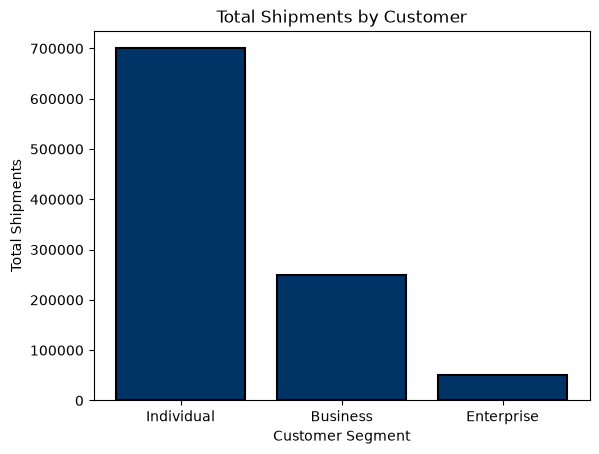

In [459]:
#Creation of Bar Chart for Question 3
plt.bar(h, d, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Total Shipments by Customer")
plt.xlabel("Customer Segment")
plt.ylabel("Total Shipments")
# plt.xticks(rotation=45, ha="right")


plt.show()

In [ ]:
# all3merged[["customer_id","customer_total_shipping_value"]].drop_duplicates().merge(shipments_by_segment)

In [ ]:
all3merged

In [460]:
#4. Which customer segment generate the highest shipping value?
shipping_value = (all3merged.groupby('customer_type')['customer_total_shipping_value'].sum().sort_values(ascending=False))
print(shipping_value)
print("The most customer shipping segment:", shipping_value.idxmax())


customer_type
Individual    2.400271e+11
Business      8.600146e+10
Enterprise    1.728869e+10
Name: customer_total_shipping_value, dtype: float64
The most customer shipping segment: Individual


In [461]:
#Define variables for Question 4
a = list(shipping_value.index.values)[0:]
c = list(shipping_value.values)[0:]

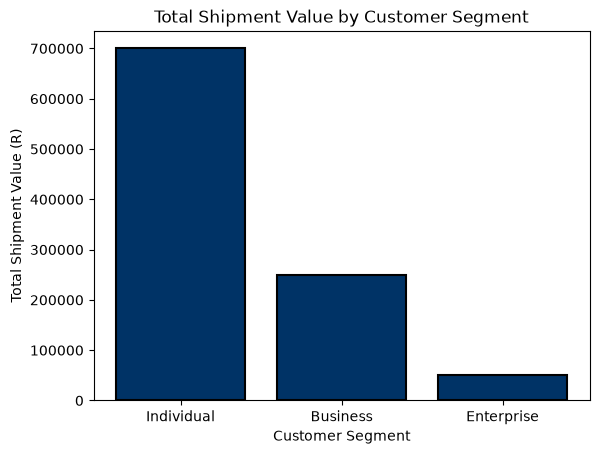

In [462]:
#Creation of Bar Chart for Question 4
plt.bar(h, d, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Total Shipment Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Shipment Value (R)")
# plt.xticks(rotation=45, ha="right")


plt.show()

In [463]:
#5. Which customer have the highest shipment frequency? 
frequent_ship = all3merged.groupby("customer_name").agg(frequent_ship=("shipment_id","count"))
# frequent_ship.reset_index()
frequent_ship.sort_values(by='frequent_ship', ascending=False).head(10)

,frequent_ship
customer_name,
Mpho Williams,2068
Precious Moyo,2062
Siyabonga Mthembu,2014
Bongani Mkhize,1995
Amanda Mthembu,1979
Tshepo Dlamini,1976
Tshepo Williams,1970
Phumzile Jacobs,1967
Thabo Moyo,1962


In [467]:
#Define variables for Question 5
d = list(frequent_ship.index.values)[0:]
e = list(frequent_ship.values)[0:]


TypeError: only 0-dimensional arrays can be converted to Python scalars

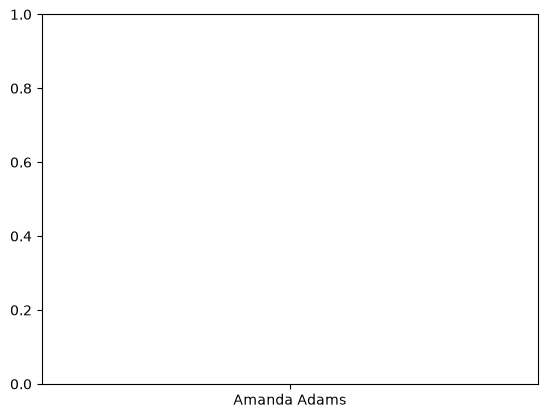

In [465]:
#Creation of Bar Chart for Question 5
plt.bar(d, e, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Top 10 Customers by Shipment Frequency")
plt.xlabel("Customer Name")
plt.ylabel("Number of Shipments")
# plt.xticks(rotation=45, ha="right")


plt.show()

In [ ]:
deliveries_cleaned = pd.read_csv("cleaned_supplyguard_data/deliveries_cleaned.csv")

In [ ]:
customers_cleaned = pd.read_csv("cleaned_supplyguard_data/customers_cleaned.csv")


In [ ]:
# #6. Which customer experienced the most delayed deliveries? 
late_deliveries = finalmerge[finalmerge["delivery_status"] == "Delayed"] ## This code does not want to work 

deliveries = late_deliveries.groupby("customer_id",).agg(
    deliveries=("delivery_status", "count")
)

deliveries.reset_index()
deliveries.sort_values(by='deliveries', ascending=False).head(10)

,deliveries
customer_id,
C097972,6
C089637,5
C065659,5
C088313,5
C039665,5
C083304,4
C072547,4
C086656,4
C070990,4


In [479]:
#Define variables for Question 6
f = list(deliveries.index.values)[0:]
i = list(deliveries.values)[0:]

In [ ]:
#Creation of Bar Chart for Question 5
plt.bar(d, e, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Top 10 Customers by Shipment Frequency")
plt.xlabel("Customer Name")
plt.ylabel("Number of Shipments")
# plt.xticks(rotation=45, ha="right")


plt.show()

# Shipment Analytics

In [ ]:
#7.Which shipment types are most common? 
shipment_count = (
    shipments_cleaned.groupby('shipment_type')['customer_id'].nunique().sort_values(ascending=False)
)
print(shipment_count)
print("Shipment type that are most common:", shipment_count.idxmax())


In [ ]:
#Define variables for Question 1: Shipment Analytics 
j = list(shipment_count.index.values)[0:]
k = list(shipment_count.values)[0:]

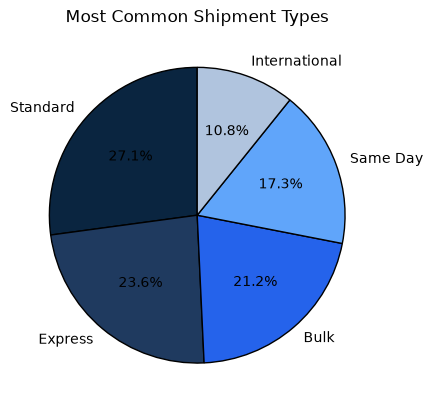

In [456]:
#Creation of Bar Chart for Question 1: Shipment Analytics
plt.pie(
    k, 
    labels=j,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#0A2540","#1F3A5F","#2563EB", "#60A5FA", "#B0C4DE"] ,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Most Common Shipment Types")

# plt.bar(j, k, color="#003366", edgecolor= "black", linewidth=1.5)
# plt.title("Most Common Shipment Types")
# plt.xlabel("Shipment Type")
# plt.ylabel("Number of Shipments")
# # plt.xticks(rotation=45, ha="right")


plt.show()

In [ ]:
deliveries_cleaned = pd.read_csv("cleaned_supplyguard_data/deliveries_cleaned.csv")


In [ ]:
shipments_cleaned = pd.read_csv("cleaned_supplyguard_data/shipments_cleaned.csv")

In [ ]:
delship = pd.merge(
    deliveries_cleaned,
    shipments_cleaned, 
    on="shipment_id",
    how="left"
)

In [ ]:
#Which delivery method are most frequently used? 

frequent_delivery = delship.groupby("delivery_method").agg(frequent_delivery=("delivery_id","count")) ##Why are we using delivery_id
# frequent_delivery.reset_index()
frequent_delivery.sort_values(by='frequent_delivery', ascending=False).head(10)
# print("Shipment type that are most common:", frequent_delivery.idxmax())

In [ ]:
#Define variables for Question 2: Shipment Analytics 
l = list(frequent_delivery.index.values)[0:]
m = list(frequent_delivery.values)[0:]

In [ ]:
plt.bar(l, m, color="#003366", edgecolor= "black", linewidth=1.5)
plt.title("Most Frequent Delivery Types")
plt.xlabel("Delivery Method")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45, ha="right")


plt.show()

In [ ]:
cust = delship.merge(customers_cleaned)

In [424]:
cust

,delivery_id,shipment_id,driver_id,vehicle_id,delivery_date,delivery_status,delivery_duration_hours,delivery_distance_km,fuel_cost_zar,customer_rating,...,weight_kg,declared_value_zar,distance_km,priority,customer_name,customer_type,province,city,registration_date,monthly_shipping_budget
0,DL000000001,S000000001,D002400,V013743,2025-12-16,Delivered Late,16.60,935.04,2504.92,2.30,...,11.97,10832.99,926.17,Low,Zanele Adams,Individual,Northern Cape,Upington,2022-06-12,33682.40
1,DL000000002,S000000002,D006019,V012835,2025-03-22,Delivered,1.06,57.08,115.77,3.30,...,73.29,90025.97,63.22,Medium,Nomsa Cele,Individual,Gauteng,Pretoria,2019-06-02,1862.17
2,DL000000003,S000000003,D006461,V000347,2026-06-26,Delivered,7.56,402.48,891.87,4.09,...,90.70,73339.17,374.86,Critical,Nomsa Molefe,Individual,Eastern Cape,Grahamstown,2019-11-25,26477.64
3,DL000000004,S000000004,D007914,V010330,2026-07-21,Delivered,3.35,147.70,609.51,3.68,...,13.26,11410.73,148.44,Medium,Ayanda Naidoo,Business,Mpumalanga,Nelspruit,2026-04-18,32574.97
4,DL000000005,S000000005,D005693,V011795,2025-07-16,Delivered,1.81,54.77,122.58,4.18,...,36.98,23529.59,61.17,Low,Nandi Molefe,Business,Free State,Welkom,2019-11-10,3591.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,DL000999996,S000999996,D005627,V000427,2025-07-08,Delivered,1.33,64.93,202.73,4.04,...,5.33,6355.05,59.99,Medium,Sibusiso Nkosi,Individual,Eastern Cape,Gqeberha,2022-04-22,12873.22
999996,DL000999997,S000999997,D001882,V006763,2026-05-05,Delivered,3.63,261.61,946.81,4.29,...,7.11,9506.09,235.68,Medium,Tshepo Botha,Individual,Eastern Cape,Mthatha,2019-05-28,1368.66
999997,DL000999998,S000999998,D008550,V010821,2025-12-17,Delivered,2.01,100.67,371.75,4.38,...,12.26,3713.83,100.23,Low,Amanda Zulu,Individual,North West,Potchefstroom,2020-12-18,5006.93
999998,DL000999999,S000999999,D008389,V004063,2026-03-04,Delivered,1.17,58.36,157.25,4.64,...,10.37,14523.73,46.44,High,Tshepo Mkhize,Individual,Gauteng,Midrand,2022-10-13,11744.83


In [ ]:
#Which provinces generate the most shipping volume?
province = cust.groupby("province").agg(frequent_delivery=("shipment_id","count")) ##Fix code. This code does not answer the question 
province.reset_index()
province.sort_values(by = "province", ascending=False)


,frequent_delivery
province,
Western Cape,179668
Northern Cape,19434
North West,39820
Mpumalanga,50195
Limpopo,70324
Kwazulu-Natal,180474
Gauteng,298437
Free State,60669
Eastern Cape,100979


In [417]:
#Define variables for Question 2: Shipment Analytics 
o = list(province.index.values)[0:]
p = list(province.values)[0:]


TypeError: only 0-dimensional arrays can be converted to Python scalars

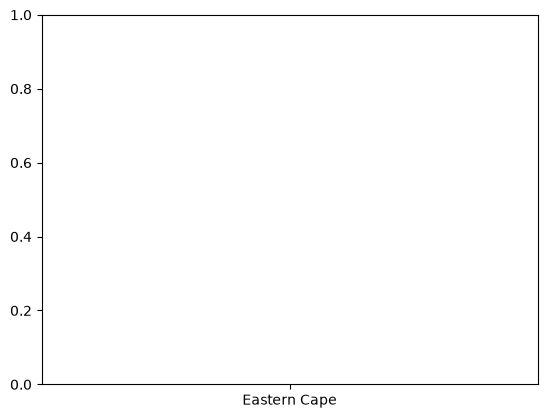

In [452]:
plt.bar(o, p, color="#003366", edgecolor= "black", linewidth=1.5) #The graph will not run because of the incorrect code above
plt.title("Total Shipping Volume by Province")
plt.xlabel("Province")
plt.ylabel("Total Shipping Volume")
# plt.xticks(rotation=45, ha="right")


plt.show()

In [428]:
#What are the busiest shipping days? 
shipments_cleaned["shipment_date"] = pd.to_datetime(shipments_cleaned["shipment_date"])
busiest_days = shipments_cleaned["shipment_date"].dt.day_name().value_counts()
print(busiest_days)

shipment_date
Thursday     144460
Wednesday    144436
Tuesday      142566
Friday       142307
Saturday     142201
Monday       142017
Sunday       142013
Name: count, dtype: int64


In [ ]:
#Define variables for Question 2: Shipment Analytics 
q = list(busiest_days.index.values)[0:]
r = list(busiest_days.values)[0:]

[np.int64(144460),
 np.int64(144436),
 np.int64(142566),
 np.int64(142307),
 np.int64(142201),
 np.int64(142017),
 np.int64(142013)]

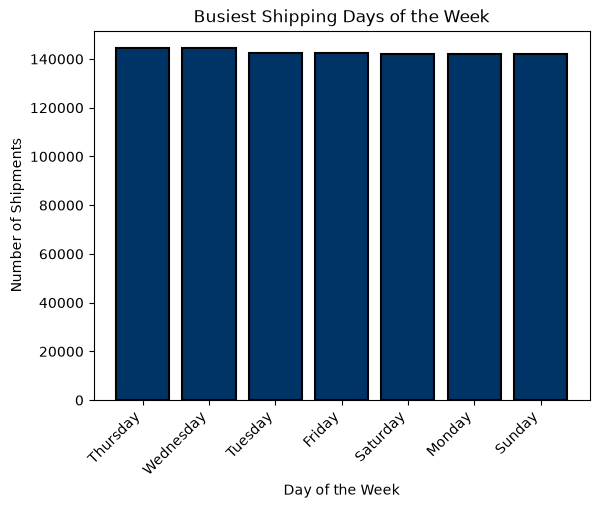

In [432]:
plt.bar(q, r, color="#003366", edgecolor= "black", linewidth=1.5) #The graph will not run because of the incorrect code above
plt.title("Busiest Shipping Days of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45, ha="right")


plt.show()

In [450]:
# #How does the shipment activity change over time?

# cust["registration_date"] = pd.to_datetime(cust["registration_date"]) - coloumn mismatch - doesnt answer the question 
# shipment_activity = (
#     cust.groupby(cust["registration_date"].dt.to_period('M')).agg(total_shipments=("shipment_id", "count")).head(10).reset_index())


cust["delivery_date"] =pd.to_datetime(cust["delivery_date"])
shipment_activity = (
     cust.groupby(cust["delivery_date"].dt.to_period("M")).agg(total_shipments=('shipment_id', "count")).reset_index())



print(shipment_activity)

   delivery_date  total_shipments
0        2025-01            49030
1        2025-02            48789
2        2025-03            53877
3        2025-04            51687
4        2025-05            53959
5        2025-06            52457
6        2025-07            53679
7        2025-08            53822
8        2025-09            52109
9        2025-10            53656
10       2025-11            51805
11       2025-12            53844
12       2026-01            54064
13       2026-02            48562
14       2026-03            54170
15       2026-04            51890
16       2026-05            54057
17       2026-06            51960
18       2026-07            53656
19       2026-08             2927


In [451]:
#Define variables for Question 2: Shipment Analytics 
s = list(busiest_days.index.values)[0:]
t = list(busiest_days.values)[0:]
s

['Thursday', 'Wednesday', 'Tuesday', 'Friday', 'Saturday', 'Monday', 'Sunday']

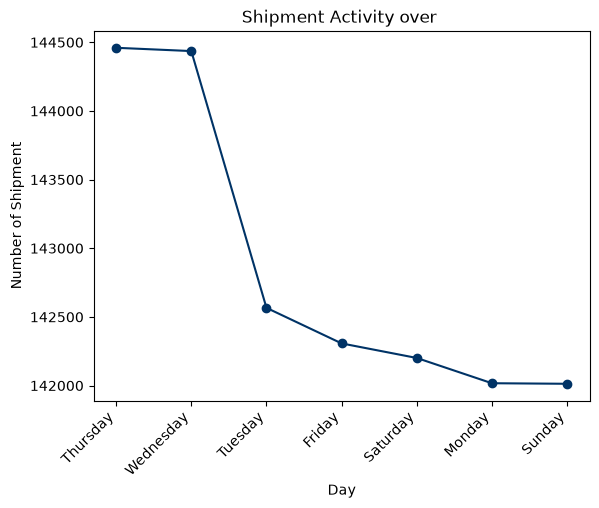

In [ ]:
plt.plot(s, t, marker="o", color= "#003366", linestyle="-" )
plt.title("Shipment Activity over ")
plt.xlabel('Day')
plt.ylabel("Number of Shipment")
plt.xticks(rotation=45, ha="right")
# plt.grid(True)   #Displays the grid. 

plt.show()